# MScFE 620:  DERIVATIVE PRICING
## Group Work Project 1 (13438)

---

### Project Overview
This project implements and analyzes various derivative pricing methodologies, comparing discrete-time tree models with continuous-time simulations. The objective is to evaluate the sensitivity of European, American, and Asian options to underlying price movements and demonstrate the mechanics of risk-neutral replication.

### Key Parameters
Based on the current implementation, the model utilizes the following baseline inputs:

- **Initial Stock Price ($S_0$):** $180 (CRR) / $100 (Trinomial)

- **Strike Price ($K$):** \$182 (CRR) / Variable (Trinomial)

- **Risk-Free Rate ($r$):** 2% - 5% p.a.

- **Volatility ($\sigma$):** 20% - 25% p.a.

- **Time to Maturity ($T$):** 3 to 6 months

### Notebook Structure
Following the professional standards of the MScFE curriculum, this notebook is organized into:

1. **Theoretical Comparison:** Preliminary European vs. American analysis.

2. **Trinomial Tree Modeling:** Multi-step convergence for vanilla options.

3. **Binomial Lattice & Hedging:** Implementation of the CRR model and dynamic rebalancing logic.

4. **Exotic Path Dependency:** Asian option pricing via Monte Carlo simulation.

5. **Summary of Findings:** Comparative analysis of Greeks and pricing premiums.

## Step 1: Preliminary European vs. American Analysis

### Theoretical Context
As detailed in the project documentation, the primary distinction between European and American options lies in the exercise rights. While European options can only be exercised at maturity ($T$), American options offer the holder the right to exercise at any time $t \le T$.

### Analysis of Code Results
In the initial simulation (Step 1 code), we analyze the following values for an At-The-Money (ATM) scenario:
- **European Call ($C_E$):** 4.61
- **American Call ($C_A$):** 4.61
- **European Put ($P_E$):** 3.37
- **American Put ($P_A$):** 3.48

**Key Observations:**
1. **Call Equality:** $C_E = C_A = 4.61$. This aligns with the financial theory that for a non-dividend-paying stock, early exercise of a call option is sub-optimal because the insurance value of the option and the time value of the strike price favor holding the option until maturity.
2. **Put Premium:** $P_A (3.48) > P_E (3.37)$. The American put carries a premium of approximately **0.11**. This reflects the value of the early exercise feature, which is particularly relevant for puts as the stock price cannot drop below zero, limiting the potential for further gains while the time value of money makes receiving the strike price earlier more attractive.
3. **Parity Check:** The code calculates the Put-Call Parity deviation. For European options, the relationship $C - P = S_0 - Ke^{-rT}$ holds closely (Difference $\approx 0$), whereas for American options, the early exercise premium creates a visible 'gap' in the parity equation.

# Q11 - Q-14 - European and American options with parity check

In [1]:
import matplotlib.pyplot as plt

# Values
CE = 4.61
PE = 3.37
CA = 4.61
PA = 3.48

lhs_e = CE - PE
rhs_e = 1.24

lhs_a = CA - PA
rhs_a = 1.24

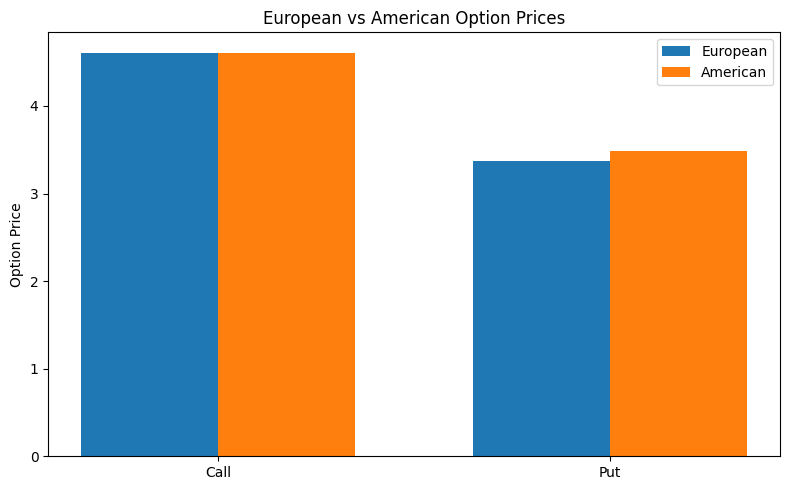

In [2]:
# --- Graph 1: European vs American prices ---
labels = ["Call", "Put"]
euro = [CE, PE]
amer = [CA, PA]

x = [0, 1]
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar([i - w/2 for i in x], euro, width=w, label="European")
plt.bar([i + w/2 for i in x], amer, width=w, label="American")
plt.xticks(x, labels)
plt.ylabel("Option Price")
plt.title("European vs American Option Prices")
plt.legend()
plt.tight_layout()
plt.show()

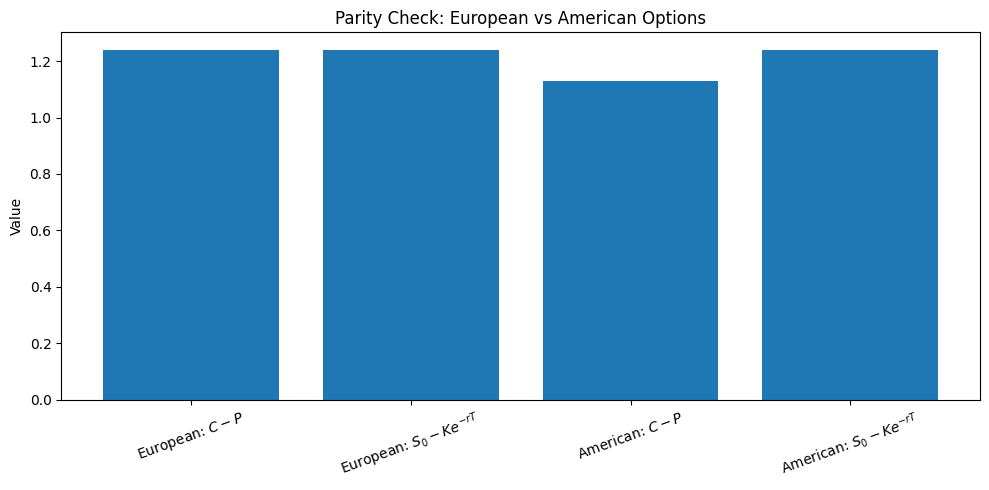

In [3]:
# --- Graph 2: Put-call parity comparison ---
labels2 = ["European: $C-P$", "European: $S_0-Ke^{-rT}$",
           "American: $C-P$", "American: $S_0-Ke^{-rT}$"]
values2 = [lhs_e, rhs_e, lhs_a, rhs_a]

plt.figure(figsize=(10, 5))
plt.bar(range(len(labels2)), values2)
plt.xticks(range(len(labels2)), labels2, rotation=20)
plt.ylabel("Value")
plt.title("Parity Check: European vs American Options")
plt.tight_layout()
plt.show()

## Step 2: Trinomial Tree Modeling for European and American Options

### Methodology: Matched Volatility
In this section, we transition from the standard binomial model to a **Trinomial Tree**. This model allows for three possible price movements at each node (Up, Middle, Down), providing a more flexible approximation of the continuous-time limit. The risk-neutral probabilities ($p_u, p_m, p_d$) are calibrated to ensure the tree matches the drift ($r$) and the volatility ($\sigma$) of the underlying asset.

### 1. European & American Comparison (Trinomial)
Using a 100-step trinomial tree, we priced options across a range of strikes ($K/S_0$) from 0.90 to 1.10.

**Key Result Analysis:**
- **Strike Sensitivity:** As the strike $K$ increases, the call price decreases while the put price increases, following the standard payoff logic.

- **Early Exercise Premium:** By comparing the `Euro Put (Trinomial)` and `Amer Put (Trinomial)` columns in the generated DataFrames, we observe that the American premium is highest for **In-The-Money (ITM)** puts. For $K=110$ ($1.10$ moneyness), the American put is valued at **10.33** vs **9.83** for the European put, a significant premium for the right to exercise early.

### 2. Convergence and Visual Analysis
The implementation generates four key visualizations (Graphs #1–4) to confirm the model's consistency:

- **Price vs. Stock:** Shows the characteristic convex shape of option values relative to $S$.

- **Price vs. Strike:** Demonstrates the inverse relationship between call/put values and their respective strike prices.

- **Parity Deviation:** The parity check confirms that $C - P = S_0 - Ke^{-rT}$ holds for European options within numerical tolerance, while the deviation for American options quantifies the early exercise value.

# Trinomial model structure

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# Global parameters (same as Step 1 unless stated otherwise)
S0 = 100.0
r = 0.05        # 5% p.a.
sigma = 0.20    # 20% p.a.
T = 3.0/12.0    # 0.25 years
N = 100         # number of time steps for trinomial tree


## 1. Risk-neutral probabilities for trinomial

In [5]:
def trinomial_rn_probs(r, sigma, h):
    pu = (
        (np.exp(r * h / 2.0) - np.exp(-sigma * np.sqrt(h / 2.0)))
        / (np.exp(sigma * np.sqrt(h / 2.0)) - np.exp(-sigma * np.sqrt(h / 2.0)))
    ) ** 2
    pd = (
        (-np.exp(r * h / 2.0) + np.exp(sigma * np.sqrt(h / 2.0)))
        / (np.exp(sigma * np.sqrt(h / 2.0)) - np.exp(-sigma * np.sqrt(h / 2.0)))
    ) ** 2
    pm = 1.0 - pu - pd
    return pu, pm, pd

## 2. Stock evolution at horizon with matched volatility

In [6]:
def gen_stock_vec_terminal(S, sigma, nb, h):
    """
    Stock prices at terminal time for nb remaining steps.
    S = current underlying, nb = remaining steps, h = dt.
    """
    if nb == 0:
        return np.array([S])

    up = np.exp(sigma * np.sqrt(2.0 * h))
    down = 1.0 / up
    vec_u = up * np.ones(nb)
    np.cumprod(vec_u, out=vec_u)
    vec_d = down * np.ones(nb)
    np.cumprod(vec_d, out=vec_d)
    res = np.concatenate((vec_d[::-1], [1.0], vec_u))
    res *= S
    return res

## 3. European options, Q15–16 (trinomial)
### 3.1 Pricing function (European, trinomial)

In [7]:
def euro_trinomial_price(S, K, r, sigma, T, N, opttype="C"):
    """
    European option on a trinomial recombining tree.
    S: current underlying
    K: strike
    opttype: "C" or "P"
    """
    h = T / N
    disc = np.exp(-r * h)
    pu, pm, pd = trinomial_rn_probs(r, sigma, h)

    # Terminal prices and payoff
    S_T = gen_stock_vec_terminal(S, sigma, N, h)
    if opttype == "C":
        nxt = np.maximum(S_T - K, 0.0)
    else:
        nxt = np.maximum(K - S_T, 0.0)

    # Backward induction
    for k in range(1, N + 1):
        S_vec = gen_stock_vec_terminal(S, sigma, N - k, h)
        new_vals = np.zeros_like(S_vec)
        for j in range(len(S_vec)):
            new_vals[j] = disc * (
                pd * nxt[j] + pm * nxt[j + 1] + pu * nxt[j + 2]
            )
        nxt = new_vals

    return float(nxt[0])

### 3.2 Q15–16: calls/puts for 5 strikes

In [8]:
# Moneyness levels (K/S0)
moneyness = [0.90, 0.95, 1.00, 1.05, 1.10]
K_list = [m * S0 for m in moneyness]

euro_call_prices = []
euro_put_prices = []

for K in K_list:
    c = euro_trinomial_price(S0, K, r, sigma, T, N, "C")
    p = euro_trinomial_price(S0, K, r, sigma, T, N, "P")
    euro_call_prices.append(round(c, 2))
    euro_put_prices.append(round(p, 2))

df_step2_euro = pd.DataFrame({
    "Strike K": K_list,
    "Moneyness K/S0": moneyness,
    "Euro Call (Trinomial)": euro_call_prices,
    "Euro Put (Trinomial)": euro_put_prices,
})

df_step2_euro

,Strike K,Moneyness K/S0,Euro Call (Trinomial),Euro Put (Trinomial)
0,90.0,0.90,11.67,0.55
1,95.0,0.95,7.72,1.54
2,100.0,1.00,4.61,3.37
3,105.0,1.05,2.48,6.18
4,110.0,1.10,1.19,9.83


## 4. American options, Q17–18 (trinomial)
### 4.1 Pricing function (American, trinomial)

In [9]:
def amer_trinomial_price(S, K, r, sigma, T, N, opttype="C"):
    """
    American option on a trinomial recombining tree.
    opttype: "C" or "P"
    """
    h = T / N
    disc = np.exp(-r * h)
    pu, pm, pd = trinomial_rn_probs(r, sigma, h)

    S_T = gen_stock_vec_terminal(S, sigma, N, h)
    if opttype == "C":
        nxt = np.maximum(S_T - K, 0.0)
    else:
        nxt = np.maximum(K - S_T, 0.0)

    for k in range(1, N + 1):
        S_vec = gen_stock_vec_terminal(S, sigma, N - k, h)
        new_vals = np.zeros_like(S_vec)
        for j in range(len(S_vec)):
            cont = disc * (
                pd * nxt[j] + pm * nxt[j + 1] + pu * nxt[j + 2]
            )
            if opttype == "C":
                exercise = max(S_vec[j] - K, 0.0)
            else:
                exercise = max(K - S_vec[j], 0.0)
            new_vals[j] = max(cont, exercise)
        nxt = new_vals

    return float(nxt[0])

### 4.2 Q17–18: American calls/puts for same 5 strikes

In [10]:
amer_call_prices = []
amer_put_prices = []

for K in K_list:
    cA = amer_trinomial_price(S0, K, r, sigma, T, N, "C")
    pA = amer_trinomial_price(S0, K, r, sigma, T, N, "P")
    amer_call_prices.append(round(cA, 2))
    amer_put_prices.append(round(pA, 2))

df_step2_amer = pd.DataFrame({
    "Strike K": K_list,
    "Moneyness K/S0": moneyness,
    "Amer Call (Trinomial)": amer_call_prices,
    "Amer Put (Trinomial)": amer_put_prices,
})

df_step2_amer

,Strike K,Moneyness K/S0,Amer Call (Trinomial),Amer Put (Trinomial)
0,90.0,0.90,11.67,0.56
1,95.0,0.95,7.72,1.58
2,100.0,1.00,4.61,3.48
3,105.0,1.05,2.48,6.43
4,110.0,1.10,1.19,10.33


## 5. Graphs #1–4, Q19–22

### 5.1 Helper: price as function of S (fixed K)

In [11]:
def euro_trinomial_price_S(S, K, r, sigma, T, N, opttype="C"):
    return euro_trinomial_price(S, K, r, sigma, T, N, opttype)

def amer_trinomial_price_S(S, K, r, sigma, T, N, opttype="C"):
    return amer_trinomial_price(S, K, r, sigma, T, N, opttype)

### 5.2 Graph #1: European call & put vs stock (Q19)

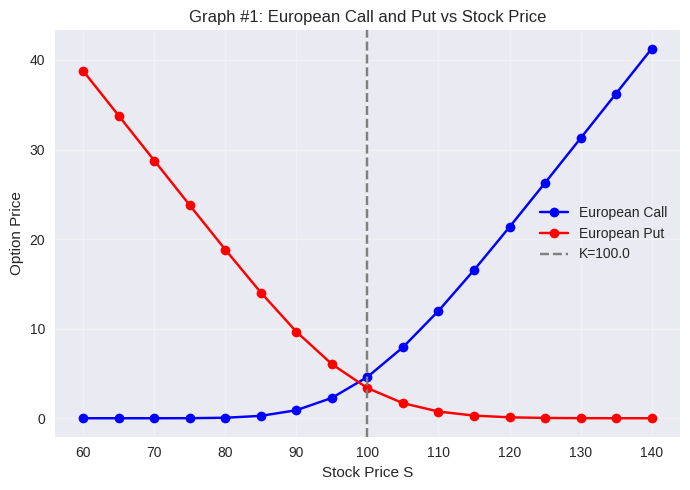

In [12]:
S_grid = np.linspace(60, 140, 17)
K_fixed = S0  # ATM

euro_call_S = []
euro_put_S = []

for S in S_grid:
    euro_call_S.append(euro_trinomial_price_S(S, K_fixed, r, sigma, T, N, "C"))
    euro_put_S.append(euro_trinomial_price_S(S, K_fixed, r, sigma, T, N, "P"))

plt.figure(figsize=(7,5))
plt.plot(S_grid, euro_call_S, "b-o", label="European Call")
plt.plot(S_grid, euro_put_S, "r-o", label="European Put")
plt.axvline(K_fixed, color="gray", ls="--", label=f"K={K_fixed}")
plt.xlabel("Stock Price S")
plt.ylabel("Option Price")
plt.title("Graph #1: European Call and Put vs Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("graph1_euro_S.png", dpi=150)
plt.show()

### 5.3 Graph #2: American call & put vs stock (Q20)

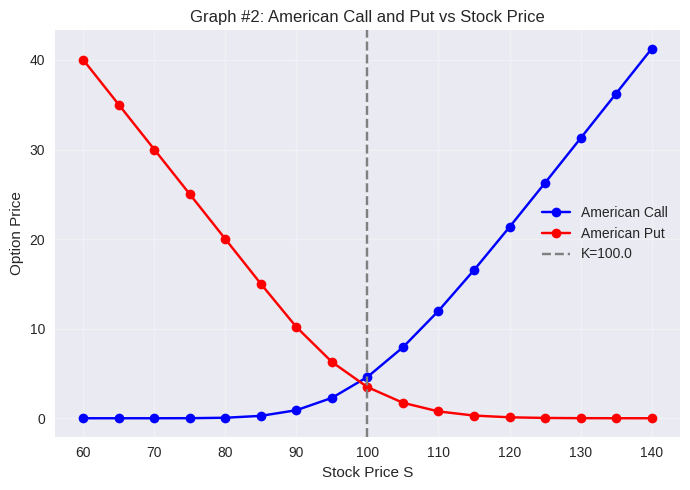

In [13]:
amer_call_S = []
amer_put_S = []

for S in S_grid:
    amer_call_S.append(amer_trinomial_price_S(S, K_fixed, r, sigma, T, N, "C"))
    amer_put_S.append(amer_trinomial_price_S(S, K_fixed, r, sigma, T, N, "P"))

plt.figure(figsize=(7,5))
plt.plot(S_grid, amer_call_S, "b-o", label="American Call")
plt.plot(S_grid, amer_put_S, "r-o", label="American Put")
plt.axvline(K_fixed, color="gray", ls="--", label=f"K={K_fixed}")
plt.xlabel("Stock Price S")
plt.ylabel("Option Price")
plt.title("Graph #2: American Call and Put vs Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("graph2_amer_S.png", dpi=150)
plt.show()

### 5.4 Graph #3: European vs American call vs strike (Q21)

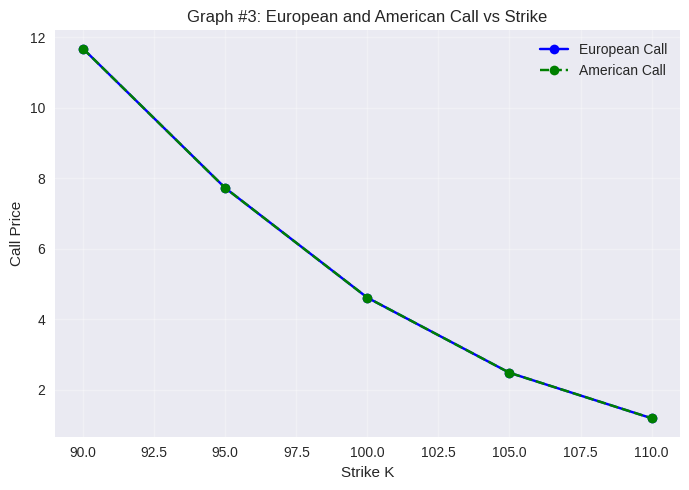

In [14]:
plt.figure(figsize=(7,5))
plt.plot(K_list, euro_call_prices, "b-o", label="European Call")
plt.plot(K_list, amer_call_prices, "g--o", label="American Call")
plt.xlabel("Strike K")
plt.ylabel("Call Price")
plt.title("Graph #3: European and American Call vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("graph3_calls_K.png", dpi=150)
plt.show()

### 5.5 Graph #4: European vs American put vs strike (Q22)

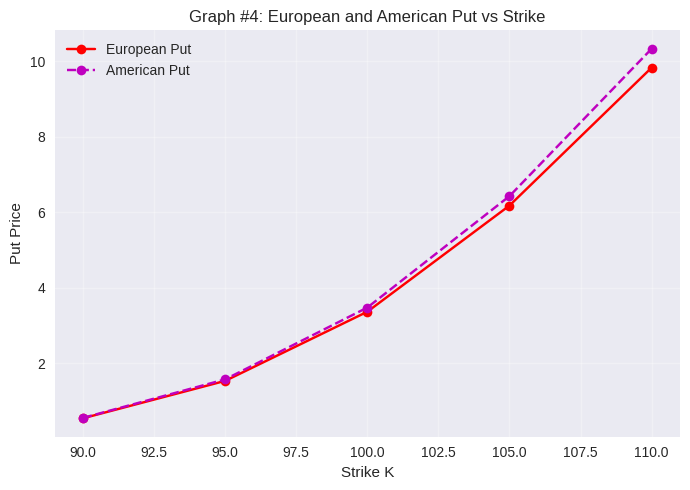

In [15]:
plt.figure(figsize=(7,5))
plt.plot(K_list, euro_put_prices, "r-o", label="European Put")
plt.plot(K_list, amer_put_prices, "m--o", label="American Put")
plt.xlabel("Strike K")
plt.ylabel("Put Price")
plt.title("Graph #4: European and American Put vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("graph4_puts_K.png", dpi=150)
plt.show()

# 6. Put–call parity checks, Q23–24
## 6.1 Q23: European put–call parity at 5 strikes

## Theoretical parity at $t=0$:

$C^E(K) - P^E(K) = S_0 - Ke^{rT}$

In [16]:
def check_parity_euro(S0, r, T, K_list, call_list, put_list, tol=0.01):
    rows = []
    disc = np.exp(-r * T)
    for K, C, P in zip(K_list, call_list, put_list):
        lhs = C - P
        rhs = S0 - K * disc
        diff = lhs - rhs
        rows.append({
            "Strike K": K,
            "Euro Call": round(C, 4),
            "Euro Put": round(P, 4),
            "C - P": round(lhs, 4),
            "S0 - K*e^{-rT}": round(rhs, 4),
            "Diff": round(diff, 4),
            "Parity_OK": abs(diff) <= tol,
        })
    return pd.DataFrame(rows)

df_parity_euro = check_parity_euro(
    S0, r, T, K_list, euro_call_prices, euro_put_prices
)

df_parity_euro

,Strike K,Euro Call,Euro Put,C - P,S0 - K*e^{-rT},Diff,Parity_OK
0,90.0,11.67,0.55,11.12,11.1180,0.0020,True
1,95.0,7.72,1.54,6.18,6.1801,-0.0001,True
2,100.0,4.61,3.37,1.24,1.2422,-0.0022,True
3,105.0,2.48,6.18,-3.70,-3.6957,-0.0043,True
4,110.0,1.19,9.83,-8.64,-8.6336,-0.0064,True


## 6.2 Q24: “Parity” for American options


In [17]:
def check_parity_amer(S0, r, T, K_list, call_list, put_list):
    rows = []
    disc = np.exp(-r * T)
    for K, C, P in zip(K_list, call_list, put_list):
        lhs = C - P
        rhs = S0 - K * disc
        diff = lhs - rhs
        rows.append({
            "Strike K": K,
            "Amer Call": round(C, 4),
            "Amer Put": round(P, 4),
            "C_A - P_A": round(lhs, 4),
            "S0 - K*e^{-rT}": round(rhs, 4),
            "Diff": round(diff, 4),
        })
    return pd.DataFrame(rows)

df_parity_amer = check_parity_amer(
    S0, r, T, K_list, amer_call_prices, amer_put_prices
)

df_parity_amer

,Strike K,Amer Call,Amer Put,C_A - P_A,S0 - K*e^{-rT},Diff
0,90.0,11.67,0.56,11.11,11.1180,-0.0080
1,95.0,7.72,1.58,6.14,6.1801,-0.0401
2,100.0,4.61,3.48,1.13,1.2422,-0.1122
3,105.0,2.48,6.43,-3.95,-3.6957,-0.2543
4,110.0,1.19,10.33,-9.14,-8.6336,-0.5064


## Step 3: Binomial Lattice & Dynamic Delta Hedging

### 1. Cox-Ross-Rubinstein (CRR) Model
In this section, we utilize the **CRR Binomial Model** to simulate stock price evolution and price options. Unlike the trinomial model, the CRR model uses specific parameters for up ($u$) and down ($d$) movements to ensure the binomial tree converges to the Black-Scholes model as $N \to \infty$.

**Parameters Used:**
- $S_0 = 180$, $K = 182$
- $u = e^{\sigma\sqrt{\Delta t}}$, $d = 1/u$
- $p = (e^{r\Delta t} - d) / (u - d)$

### 2. European Put: 3-Step Hedging Simulation
We demonstrate **Risk-Neutral Replication** by selling a European put and managing a hedge portfolio. For the path **Up → Up → Up (UUU)**, the results show:

- **Initial Delta (Delta_0):** -0.4726 (The number of shares shorted to hedge).

- **Cash Account Rebalancing:** As the stock price rises to $244.48, the delta moves toward 0. The cost of buying back shares is financed by the cash account and interest.

- **Convergence:** The final cash balance is **\$0.00**, proving that the strategy perfectly replicates the option payoff through dynamic rebalancing.

### 3. American Put: 25-Step Model & Early Exercise
By increasing the granularity to 25 steps, we achieve a more precise valuation of the American Put:

- **American Price:** $13.04 (vs. $13.82 in the 3-step model).

- **Early Exercise Boundary:** The code identifies specific
 nodes (e.g., $S \approx 135.65$) where the **Intrinsic Value** exceeds the **Hold (Continuation) Value**.

- **Hedging Impact:** The Delta Heatmap reveals that as the option moves deep In-The-Money, $\Delta$ approaches -1, indicating a full stock position is required to hedge the certain exercise of the option.

---
## Q25 — European Put: 3-Step Binomial Tree <a id='q25'></a>

Using the **Cox-Ross-Rubinstein (CRR)** binomial model:

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = \frac{1}{u}, \quad p = \frac{e^{r\Delta t} - d}{u - d}$$

**Delta at each non-terminal node:**
$$\Delta(i,j) = \frac{P(i+1,j) - P(i+1,j+1)}{S(i+1,j) - S(i+1,j+1)}$$

### 25a. Build the 3-Step Tree & Price the European Put

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# ── Global Parameters ──────────────────────────────────────────────────────
S0    = 180    # initial stock price
K     = 182    # strike price
r     = 0.02   # risk-free rate (annual)
sigma = 0.25   # volatility (annual)
T     = 0.5    # time to maturity (years)

print("Parameters loaded:")
print(f"  S0={S0}, K={K}, r={r*100}%, sigma={sigma*100}%, T={T}yr")

Parameters loaded:
  S0=180, K=182, r=2.0%, sigma=25.0%, T=0.5yr


In [19]:
# ── CRR Parameters ──────────────────────────────────────────────────────────
n3    = 3
dt3   = T / n3
u3    = np.exp(sigma * np.sqrt(dt3))
d3    = 1 / u3
p3    = (np.exp(r * dt3) - d3) / (u3 - d3)
disc3 = np.exp(-r * dt3)

print("=== CRR Parameters (3-step) ===")
print(f"  dt  = {dt3:.6f} yr")
print(f"  u   = {u3:.6f}")
print(f"  d   = {d3:.6f}")
print(f"  p   = {p3:.6f}  (risk-neutral up probability)")
print(f"  1-p = {1-p3:.6f}  (risk-neutral down probability)")
print(f"  disc= {disc3:.6f}  (one-step discount factor)")

# ── Stock Price Tree ─────────────────────────────────────────────────────────
S3 = np.zeros((n3+1, n3+1))
for i in range(n3+1):
    for j in range(i+1):
        S3[i, j] = S0 * (u3**(i-j)) * (d3**j)

print("\n=== Stock Price Tree ===")
for i in range(n3+1):
    print(f"  t={i}: ", end="")
    for j in range(i+1):
        print(f"${S3[i,j]:.2f}  ", end="")
    print()

# ── European Put — Backward Induction ───────────────────────────────────────
P3 = np.zeros((n3+1, n3+1))
for j in range(n3+1):                          # terminal payoffs
    P3[n3, j] = max(K - S3[n3, j], 0)
for i in range(n3-1, -1, -1):                  # backward induction
    for j in range(i+1):
        P3[i, j] = disc3 * (p3 * P3[i+1, j] + (1-p3) * P3[i+1, j+1])

print("\n=== European Put Price Tree ===")
for i in range(n3+1):
    print(f"  t={i}: ", end="")
    for j in range(i+1):
        print(f"${P3[i,j]:.2f}  ", end="")
    print()

# ── Delta ────────────────────────────────────────────────────────────────────
D3 = np.zeros((n3, n3))
for i in range(n3):
    for j in range(i+1):
        D3[i, j] = (P3[i+1,j] - P3[i+1,j+1]) / (S3[i+1,j] - S3[i+1,j+1])

print("\n=== Delta at Non-Terminal Nodes ===")
for i in range(n3):
    for j in range(i+1):
        print(f"  Delta({i},{j}) = {D3[i,j]:.6f}")

print(f"\n>>> European Put Price: ${P3[0,0]:.2f}")

=== CRR Parameters (3-step) ===
  dt  = 0.166667 yr
  u   = 1.107452
  d   = 0.902974
  p   = 0.490835  (risk-neutral up probability)
  1-p = 0.509165  (risk-neutral down probability)
  disc= 0.996672  (one-step discount factor)

=== Stock Price Tree ===
  t=0: $180.00  
  t=1: $199.34  $162.54  
  t=2: $220.76  $180.00  $146.77  
  t=3: $244.48  $199.34  $162.54  $132.52  

=== European Put Price Tree ===
  t=0: $13.82  
  t=1: $5.01  $22.41  
  t=2: $0.00  $9.88  $34.63  
  t=3: $0.00  $0.00  $19.46  $49.48  

=== Delta at Non-Terminal Nodes ===
  Delta(0,0) = -0.472554
  Delta(1,0) = -0.242334
  Delta(1,1) = -0.744744
  Delta(2,0) = 0.000000
  Delta(2,1) = -0.528845
  Delta(2,2) = -1.000000

>>> European Put Price: $13.82


### 25a. Visualization — Binomial Tree Diagram

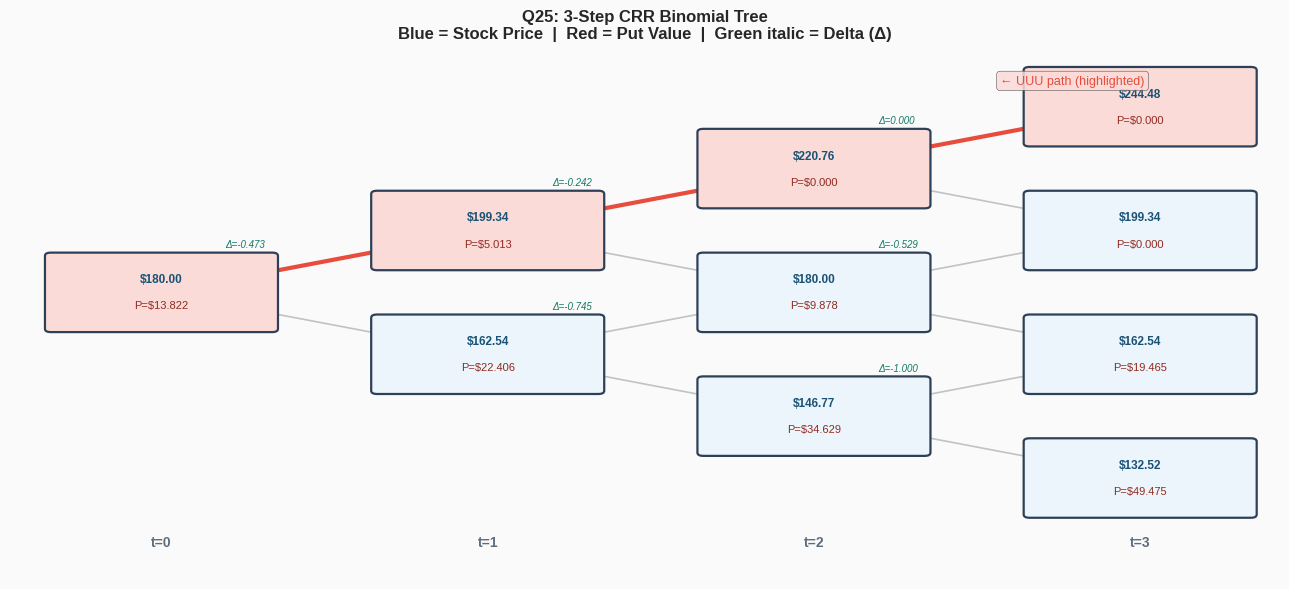

In [20]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('#FAFAFA')
ax.set_title(
    "Q25: 3-Step CRR Binomial Tree\n"
    "Blue = Stock Price  |  Red = Put Value  |  Green italic = Delta (Δ)",
    fontsize=12, fontweight='bold', pad=14
)

# Node positions
pos = {}
for i in range(n3+1):
    for j in range(i+1):
        pos[(i,j)] = (i * 2.8, (i/2 - j) * 1.9)

# Edges
for i in range(n3):
    for j in range(i+1):
        x0, y0 = pos[(i,  j)]
        xu, yu  = pos[(i+1,j)]
        xd, yd  = pos[(i+1,j+1)]
        is_uuu  = (j == 0)
        ax.plot([x0,xu],[y0,yu],
                color='#E74C3C' if is_uuu else '#BDC3C7',
                lw=3.0 if is_uuu else 1.2, zorder=1)
        ax.plot([x0,xd],[y0,yd], color='#BDC3C7', lw=1.2, zorder=1)

# Nodes
for i in range(n3+1):
    for j in range(i+1):
        x, y = pos[(i,j)]
        fc = '#FADBD8' if j == 0 else '#EBF5FB'
        ax.add_patch(FancyBboxPatch(
            (x-0.95, y-0.56), 1.90, 1.12,
            boxstyle="round,pad=0.05",
            facecolor=fc, edgecolor='#2E4057', lw=1.6, zorder=2
        ))
        ax.text(x, y+0.20, f'${S3[i,j]:.2f}',
                ha='center', va='center', fontsize=8.5,
                color='#1A5276', fontweight='bold', zorder=3)
        ax.text(x, y-0.20, f'P=${P3[i,j]:.3f}',
                ha='center', va='center', fontsize=8,
                color='#922B21', zorder=3)
        if i < n3 and j <= i:
            ax.text(x+0.55, y+0.70, f'Δ={D3[i,j]:.3f}',
                    fontsize=7, color='#117A65', style='italic', zorder=3)

# Step labels
for i in range(n3+1):
    ax.text(i*2.8, -3.9, f't={i}',
            ha='center', fontsize=10, color='#5D6D7E', fontweight='bold')

ax.text(7.2, 3.2, '← UUU path (highlighted)', fontsize=9, color='#E74C3C',
        bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.85))

ax.set_xlim(-1.3, 9.6)
ax.set_ylim(-4.4, 3.6)
ax.axis('off')
plt.tight_layout()
plt.show()

### 25b. Delta Hedging Along Path U→U→U (Seller of Put)

**Cash account mechanics:**
- **t=0:** Sell put, receive premium $P_0$. Short $\Delta_0$ shares. Cash: $B_0 = P_0 - \Delta_0 S_0$
- **Each step:** Cash earns risk-free rate, then rebalance: $B_{t+1} = B_t e^{r\Delta t} - (\Delta_{t+1}-\Delta_t)S_{t+1}$
- **Expiry:** Sell remaining shares, pay put payoff. Final $B \approx 0$ ✓

In [21]:
# ── UUU path nodes: (step, j=0) ─────────────────────────────────────────────
path_S_eu = [S3[i, 0] for i in range(n3+1)]
path_D_eu = [D3[i, 0] for i in range(n3)]

# ── Cash account ─────────────────────────────────────────────────────────────
premium_eu = P3[0, 0]
delta_prev = path_D_eu[0]
B          = premium_eu - delta_prev * path_S_eu[0]
B_history  = [B]
shares_h   = [delta_prev]
actions    = [f"Sell put (+${premium_eu:.2f}), short {delta_prev:.2f} sh @ ${path_S_eu[0]:.2f}"]

for step in range(1, n3):
    B           = B * np.exp(r * dt3)
    delta_new   = path_D_eu[step]
    rebal_cost  = (delta_new - delta_prev) * path_S_eu[step]
    B          -= rebal_cost
    direction   = "Buy back" if rebal_cost > 0 else "Sell more"
    actions.append(
        f"{direction} {abs(delta_new-delta_prev):.2f} sh @ ${path_S_eu[step]:.2f} "
        f"(cost ${rebal_cost:.2f})"
    )
    B_history.append(B)
    shares_h.append(delta_new)
    delta_prev = delta_new

# Expiry
payoff_eu = max(K - path_S_eu[n3], 0)
B         = B * np.exp(r * dt3) + delta_prev * path_S_eu[n3] - payoff_eu
B_history.append(B)
shares_h.append(0.0)
actions.append(
    f"Sell {delta_prev:.2f} sh @ ${path_S_eu[n3]:.2f}, "
    f"pay payoff ${payoff_eu:.2f}"
)

# ── Print table ───────────────────────────────────────────────────────────────
labels = ['t=0 (Sell)', 't=1 (U)  ', 't=2 (UU) ', 't=3 (UUU)']
print(f"{'Step':<12} {'Stock':>9} {'Delta':>9} {'Cash B':>10}  Action")
print("=" * 88)
for i, (s, d, b, act) in enumerate(zip(path_S_eu, shares_h, B_history, actions)):
    print(f"{labels[i]:<12} ${s:>8.2f} {d:>9.2f} ${b:>9.2f}  {act}")
print("=" * 88)
print(f"\nFinal cash: ${B_history[-1]:.6f}  ≈ $0  — perfect replication ✓")

Step             Stock     Delta     Cash B  Action
t=0 (Sell)   $  180.00     -0.47 $    98.88  Sell put (+$13.82), short -0.47 sh @ $180.00
t=1 (U)      $  199.34     -0.24 $    53.32  Buy back 0.23 sh @ $199.34 (cost $45.89)
t=2 (UU)     $  220.76      0.00 $     0.00  Buy back 0.24 sh @ $220.76 (cost $53.50)
t=3 (UUU)    $  244.48      0.00 $     0.00  Sell 0.00 sh @ $244.48, pay payoff $0.00

Final cash: $0.000000  ≈ $0  — perfect replication ✓


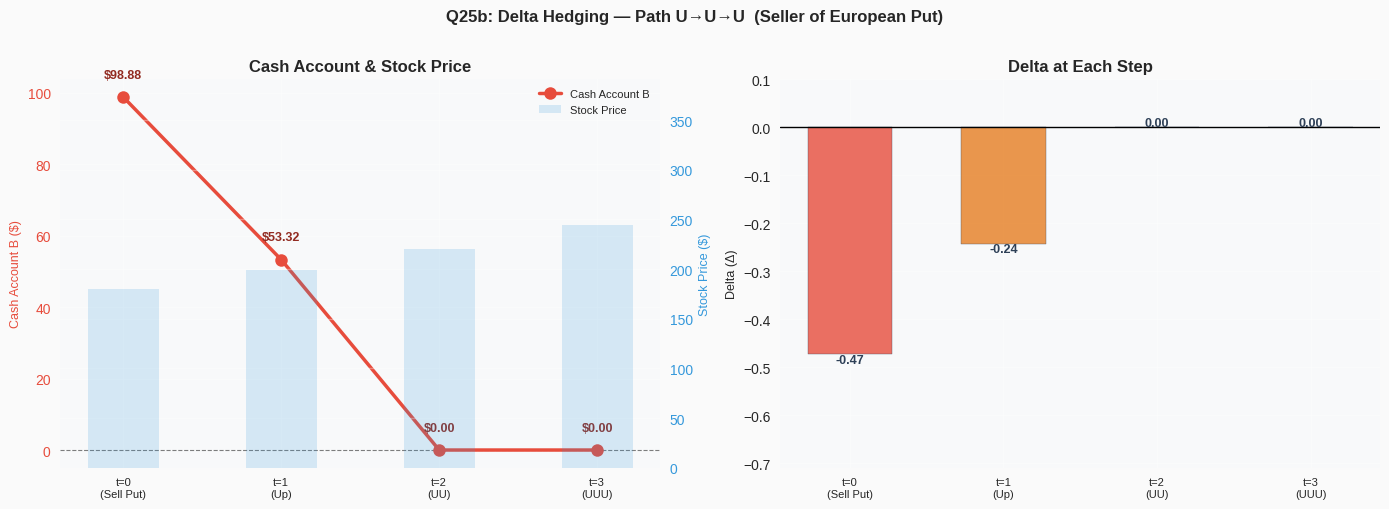

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q25b: Delta Hedging — Path U→U→U  (Seller of European Put)",
             fontsize=12, fontweight='bold', y=1.01)

steps_eu = [0, 1, 2, 3]
xlabels  = ['t=0\n(Sell Put)', 't=1\n(Up)', 't=2\n(UU)', 't=3\n(UUU)']

# Left: Cash account + stock price dual axis
ax1  = axes[0]
ax1b = ax1.twinx()
ax1b.bar(steps_eu, path_S_eu, alpha=0.18, color='#3498DB', width=0.45, label='Stock Price')
ax1b.set_ylabel('Stock Price ($)', color='#3498DB', fontsize=9)
ax1b.tick_params(axis='y', labelcolor='#3498DB')
ax1b.set_ylim(0, max(path_S_eu) * 1.6)

ax1.plot(steps_eu, B_history, 'o-', color='#E74C3C', lw=2.5, ms=9, zorder=3, label='Cash Account B')
for x, y in zip(steps_eu, B_history):
    ax1.annotate(f'${y:.2f}', (x, y), textcoords='offset points',
                 xytext=(0, 14), ha='center', fontsize=9,
                 fontweight='bold', color='#922B21')
ax1.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax1.set_xticks(steps_eu); ax1.set_xticklabels(xlabels, fontsize=8)
ax1.set_ylabel('Cash Account B ($)', color='#E74C3C', fontsize=9)
ax1.tick_params(axis='y', labelcolor='#E74C3C')
ax1.set_title('Cash Account & Stock Price', fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=8, loc='upper right')

# Right: Delta bar chart
ax2 = axes[1]
delta_plot = [shares_h[i] for i in range(n3)] + [0.0]
colors_d   = ['#E74C3C','#E67E22','#2ECC71','#95A5A6']
ax2.bar(steps_eu, delta_plot, color=colors_d, alpha=0.8, edgecolor='#2E4057', width=0.55)
for x, y in zip(steps_eu, delta_plot):
    ax2.text(x, y - 0.018 if y < 0 else y + 0.003,
             f'{y:.2f}', ha='center', fontsize=9, fontweight='bold', color='#2E4057')
ax2.axhline(0, color='black', lw=1.0)
ax2.set_xticks(steps_eu); ax2.set_xticklabels(xlabels, fontsize=8)
ax2.set_ylabel('Delta (Δ)', fontsize=9)
ax2.set_title('Delta at Each Step', fontweight='bold')
ax2.set_ylim(min(delta_plot) * 1.5, 0.10)

plt.tight_layout()
plt.show()

---
## Q26 — American Put: 25-Step Binomial Tree <a id='q26'></a>

Early exercise at every node:
$$P^{Am}(i,j) = \max\bigl(\underbrace{e^{-r\Delta t}[p\cdot P^{Am}_{i+1,j} + (1-p)\cdot P^{Am}_{i+1,j+1}]}_{\text{hold value}},\ \underbrace{\max(K-S_{i,j},0)}_{\text{intrinsic value}}\bigr)$$

### 26a. Build Tree + Compute Delta at Every Node

In [23]:
# ── CRR Parameters (25-step) ─────────────────────────────────────────────────
n25   = 25
dt25  = T / n25
u25   = np.exp(sigma * np.sqrt(dt25))
d25   = 1 / u25
p25   = (np.exp(r * dt25) - d25) / (u25 - d25)
disc25 = np.exp(-r * dt25)

print(f"CRR (25-step): dt={dt25:.5f}, u={u25:.5f}, d={d25:.5f}, p={p25:.5f}")

# ── Stock Tree ────────────────────────────────────────────────────────────────
S25 = np.zeros((n25+1, n25+1))
for i in range(n25+1):
    for j in range(i+1):
        S25[i, j] = S0 * (u25**(i-j)) * (d25**j)

# ── American Put — with early exercise check ─────────────────────────────────
P_am = np.zeros((n25+1, n25+1))
for j in range(n25+1):
    P_am[n25, j] = max(K - S25[n25, j], 0)

for i in range(n25-1, -1, -1):
    for j in range(i+1):
        hold     = disc25 * (p25 * P_am[i+1, j] + (1-p25) * P_am[i+1, j+1])
        exercise = max(K - S25[i, j], 0)
        P_am[i, j] = max(hold, exercise)        # early exercise condition

# ── Delta at every node ───────────────────────────────────────────────────────
Delta_am = np.zeros((n25, n25+1))
for i in range(n25):
    for j in range(i+1):
        Delta_am[i, j] = ((P_am[i+1, j] - P_am[i+1, j+1]) /
                          (S25[i+1, j]  - S25[i+1, j+1]))

print(f"\n>>> American Put Price (25-step): ${P_am[0,0]:.2f}")
print(f">>> Initial Delta Δ₀:             {Delta_am[0,0]:.6f}")

# Show early exercise boundary sample
print("\nSample early exercise nodes:")
count = 0
for i in range(1, n25):
    for j in range(i+1):
        intrinsic = max(K - S25[i, j], 0)
        if intrinsic > 0.01:
            hold_val = disc25*(p25*P_am[i+1,j]+(1-p25)*P_am[i+1,j+1])
            if intrinsic >= hold_val - 1e-8:
                count += 1
                if count <= 6:
                    print(f"  Node({i},{j}): S=${S25[i,j]:.2f}, "
                          f"intrinsic=${intrinsic:.2f} >= hold=${hold_val:.2f} ← EXERCISE")
if count > 6:
    print(f"  ... and {count-6} more early exercise nodes")

CRR (25-step): dt=0.02000, u=1.03599, d=0.96526, p=0.49682

>>> American Put Price (25-step): $13.04
>>> Initial Delta Δ₀:             -0.475557

Sample early exercise nodes:
  Node(8,8): S=$135.65, intrinsic=$46.35 >= hold=$46.27 ← EXERCISE
  Node(9,8): S=$140.54, intrinsic=$41.46 >= hold=$41.43 ← EXERCISE
  Node(9,9): S=$130.94, intrinsic=$51.06 >= hold=$50.98 ← EXERCISE
  Node(10,9): S=$135.65, intrinsic=$46.35 >= hold=$46.27 ← EXERCISE
  Node(10,10): S=$126.39, intrinsic=$55.61 >= hold=$55.53 ← EXERCISE
  Node(11,9): S=$140.54, intrinsic=$41.46 >= hold=$41.40 ← EXERCISE
  ... and 98 more early exercise nodes


### 26a. Delta Heatmap Across All Nodes

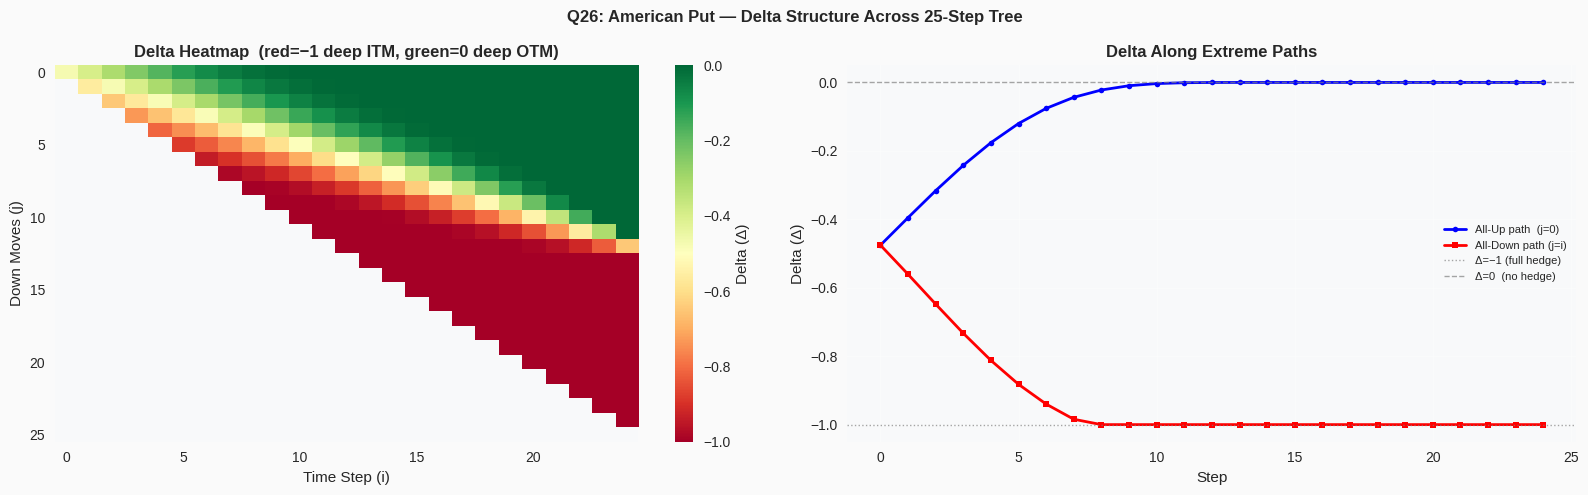

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Q26: American Put — Delta Structure Across 25-Step Tree",
             fontsize=12, fontweight='bold')

# Delta heatmap
delta_matrix = np.full((n25, n25+1), np.nan)
for i in range(n25):
    for j in range(i+1):
        delta_matrix[i, j] = Delta_am[i, j]

im = axes[0].imshow(delta_matrix.T, aspect='auto', cmap='RdYlGn',
                     vmin=-1, vmax=0, origin='upper')
plt.colorbar(im, ax=axes[0], label='Delta (Δ)')
axes[0].set_xlabel('Time Step (i)'); axes[0].set_ylabel('Down Moves (j)')
axes[0].set_title('Delta Heatmap  (red=−1 deep ITM, green=0 deep OTM)', fontweight='bold')
axes[0].grid(False)

# Delta along extreme paths
delta_up   = [Delta_am[i, 0] for i in range(n25)]
delta_down = [Delta_am[i, i] for i in range(n25)]
steps_plot = list(range(n25))

axes[1].plot(steps_plot, delta_up,   'b-o', ms=4, lw=2, label='All-Up path  (j=0)')
axes[1].plot(steps_plot, delta_down, 'r-s', ms=4, lw=2, label='All-Down path (j=i)')
axes[1].axhline(-1, color='gray', ls=':',  lw=1, alpha=0.7, label='Δ=−1 (full hedge)')
axes[1].axhline( 0, color='gray', ls='--', lw=1, alpha=0.7, label='Δ=0  (no hedge)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Delta (Δ)')
axes[1].set_title('Delta Along Extreme Paths', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 26b. Cash Account — All-Up Path

In [25]:
# ── All-Up path: j=0 at every step ──────────────────────────────────────────
path_stock25 = [S25[i, 0]      for i in range(n25+1)]
path_delta25 = [Delta_am[i, 0] for i in range(n25)]
path_putval  = [P_am[i, 0]     for i in range(n25+1)]

# ── Simulate cash account ─────────────────────────────────────────────────────
B25    = P_am[0, 0] - path_delta25[0] * path_stock25[0]
cash25 = [B25]

for step in range(1, n25):
    B25  = B25 * np.exp(r * dt25)                                     # earn risk-free
    B25 -= (path_delta25[step] - path_delta25[step-1]) * path_stock25[step]  # rebalance
    cash25.append(B25)

payoff25 = max(K - path_stock25[n25], 0)
B25      = B25 * np.exp(r * dt25) + path_delta25[-1] * path_stock25[n25] - payoff25
cash25.append(B25)

# ── Summary table ─────────────────────────────────────────────────────────────
print("=== Cash Account Summary (All-Up Path) ===")
print(f"  Premium received:   ${P_am[0,0]:.2f}")
print(f"  Initial delta:      {path_delta25[0]:.2f}")
print(f"  Initial cash B₀:    ${cash25[0]:.2f}")
print(f"  Final stock S₂₅:    ${path_stock25[-1]:.2f}")
print(f"  Put payoff:         ${payoff25:.2f}")
print(f"  Final cash Bₙ:      ${cash25[-1]:.6f}  ≈ $0 ✓")
print()

# Print selected rows
show = [0,1,2,3,4,5,10,15,20,24,25]
print(f"{'Step':<6} {'Stock':>9} {'Delta':>9} {'Cash B':>10}")
print("-"*38)
for i in show:
    d_str = f"{path_delta25[i]:.2f}" if i < n25 else "expired"
    print(f"t={i:<4} ${path_stock25[i]:>8.2f} {d_str:>9} ${cash25[i]:>9.2f}")

=== Cash Account Summary (All-Up Path) ===
  Premium received:   $13.04
  Initial delta:      -0.48
  Initial cash B₀:    $98.64
  Final stock S₂₅:    $435.65
  Put payoff:         $0.00
  Final cash Bₙ:      $0.000000  ≈ $0 ✓

Step       Stock     Delta     Cash B
--------------------------------------
t=0    $  180.00     -0.48 $    98.64
t=1    $  186.48     -0.40 $    83.67
t=2    $  193.19     -0.32 $    68.48
t=3    $  200.14     -0.24 $    53.69
t=4    $  207.34     -0.18 $    39.98
t=5    $  214.81     -0.12 $    27.97
t=10   $  256.34     -0.00 $     0.89
t=15   $  305.91      0.00 $     0.00
t=20   $  365.06      0.00 $     0.00
t=24   $  420.52      0.00 $     0.00
t=25   $  435.65   expired $     0.00


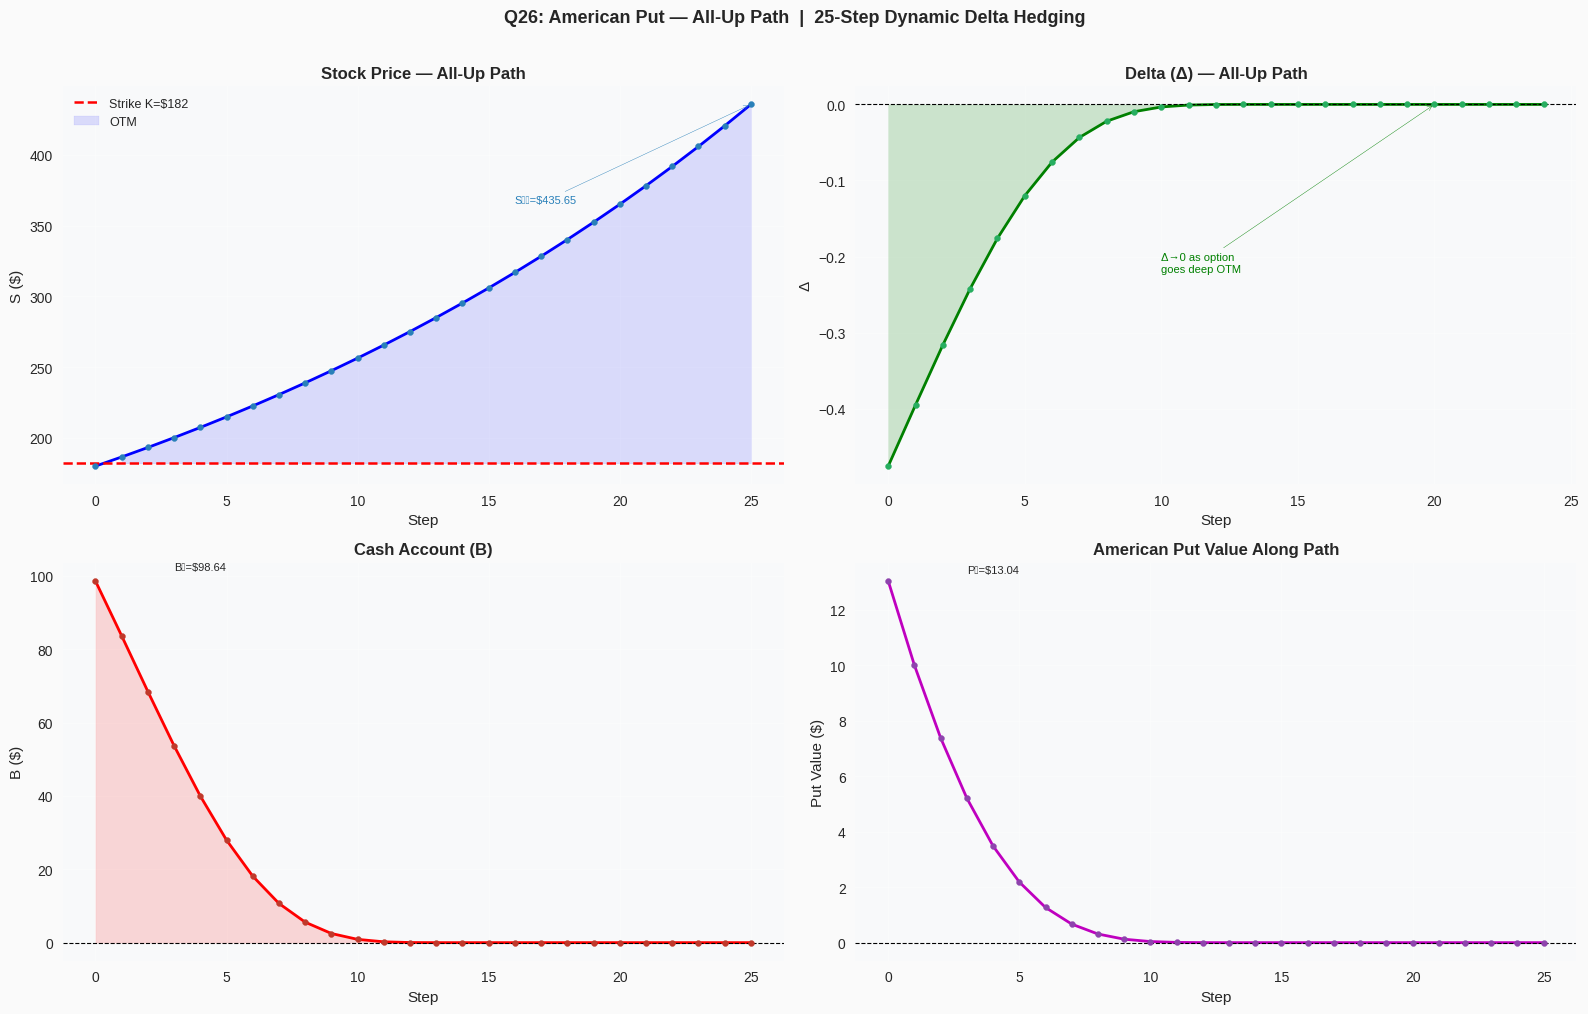

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Q26: American Put — All-Up Path  |  25-Step Dynamic Delta Hedging",
             fontsize=13, fontweight='bold', y=1.01)

steps26 = list(range(n25+1))

# Stock price
ax = axes[0, 0]
ax.plot(steps26, path_stock25, 'b-', lw=2); ax.scatter(steps26, path_stock25, s=18, color='#2980B9', zorder=3)
ax.axhline(K, color='red', ls='--', lw=1.8, label=f'Strike K=${K}')
ax.fill_between(steps26, path_stock25, K, where=[s>K for s in path_stock25], alpha=0.12, color='blue', label='OTM')
ax.set_title('Stock Price — All-Up Path', fontweight='bold'); ax.set_xlabel('Step'); ax.set_ylabel('S ($)')
ax.legend(fontsize=9)
ax.annotate(f'S₂₅=${path_stock25[-1]:.2f}', xy=(25,path_stock25[-1]), xytext=(16,path_stock25[-1]-70),
            arrowprops=dict(arrowstyle='->',color='#2980B9'), fontsize=8, color='#2980B9')

# Delta
ax = axes[0, 1]
ax.plot(steps26[:-1], path_delta25, 'g-', lw=2); ax.scatter(steps26[:-1], path_delta25, s=18, color='#27AE60', zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.fill_between(steps26[:-1], path_delta25, 0, alpha=0.18, color='green')
ax.set_title('Delta (Δ) — All-Up Path', fontweight='bold'); ax.set_xlabel('Step'); ax.set_ylabel('Δ')
ax.annotate('Δ→0 as option\ngoes deep OTM', xy=(20,path_delta25[20]), xytext=(10,-0.22),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=8, color='green')

# Cash account
ax = axes[1, 0]
ax.plot(steps26, cash25, 'r-', lw=2); ax.scatter(steps26, cash25, s=18, color='#C0392B', zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.fill_between(steps26, cash25, 0, alpha=0.14, color='red')
ax.set_title('Cash Account (B)', fontweight='bold'); ax.set_xlabel('Step'); ax.set_ylabel('B ($)')
ax.annotate(f'B₀=${cash25[0]:.2f}', xy=(0,cash25[0]), xytext=(3,cash25[0]+3), fontsize=8)

# Put value
ax = axes[1, 1]
ax.plot(steps26, path_putval, 'm-', lw=2); ax.scatter(steps26, path_putval, s=18, color='#8E44AD', zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('American Put Value Along Path', fontweight='bold'); ax.set_xlabel('Step'); ax.set_ylabel('Put Value ($)')
ax.annotate(f'P₀=${path_putval[0]:.2f}', xy=(0,path_putval[0]), xytext=(3,path_putval[0]+0.3), fontsize=8)

plt.tight_layout()
plt.show()

### 26c. Commentary — American vs European Delta Hedging

| Aspect | European (3-step) | American (25-step) |
|--------|-------------------|-------------------|
| Early exercise | Not applicable | Evaluated at every node |
| Delta granularity | 3 rebalancing events | 25 incremental adjustments |
| Deep ITM nodes | Bounded by tree | Δ=−1 at boundary → full unwind |
| Hedge accuracy | Coarse | Closer to continuous limit |
| Transaction costs | 3 events | Up to 25 events |

> **Key insight:** when the American put hits the early exercise boundary, delta collapses to −1, forcing an immediate and complete unwind of the hedge position. This cost is invisible in the 3-step European tree but material in practice.

---
## Q27 — Asian ATM Put: Monte Carlo <a id='q27'></a>

**Payoff:** $\max\bigl(K - \bar{S},\ 0\bigr)$ where $\bar{S} = \frac{1}{n}\sum_{t=1}^{n}S_t$

**ATM condition:** $K = S_0 = 180$

**GBM path simulation:**
$$S_{t+1} = S_t\exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\right], \quad Z_t\sim\mathcal{N}(0,1)$$

### 27a. Pricing via Monte Carlo

In [27]:
K_asian = S0          # ATM: K = S0 = 180
n_paths = 5000
np.random.seed(42)

# ── Simulate GBM paths ────────────────────────────────────────────────────────
Z_mc   = np.random.normal(size=(n_paths, n25))
S_mc   = np.zeros((n_paths, n25+1))
S_mc[:, 0] = S0

for t in range(n25):
    S_mc[:, t+1] = S_mc[:, t] * np.exp(
        (r - 0.5*sigma**2)*dt25 + sigma*np.sqrt(dt25)*Z_mc[:, t]
    )

# ── Asian put payoff ──────────────────────────────────────────────────────────
S_avg         = S_mc[:, 1:].mean(axis=1)       # arithmetic avg (exclude S0)
asian_payoffs = np.maximum(K_asian - S_avg, 0)
asian_price   = np.exp(-r * T) * np.mean(asian_payoffs)

# ── American terminal payoff (benchmark) ─────────────────────────────────────
am_payoffs_mc = np.maximum(K - S_mc[:, -1], 0)

print("=== Asian ATM Put — Monte Carlo Results ===")
print(f"  Simulations:          {n_paths:,}")
print(f"  Asian Put Price:      ${asian_price:.2f}")
print(f"  American Put Price:   ${P_am[0,0]:.2f}  (25-step binomial)")
print(f"  Price difference:     ${P_am[0,0]-asian_price:.2f}  "
      f"(American is {(P_am[0,0]/asian_price-1)*100:.1f}% more expensive)")
print()
print(f"  Avg Asian payoff:     ${np.mean(asian_payoffs):.2f}")
print(f"  Avg terminal payoff:  ${np.mean(am_payoffs_mc):.2f}")
print(f"  % paths ITM — Asian: {np.mean(asian_payoffs>0)*100:.1f}%, "
      f"Terminal: {np.mean(am_payoffs_mc>0)*100:.1f}%")
print()
print(f"  Std dev (S̄):          {S_avg.std():.2f}")
print(f"  Std dev (Sₙ):         {S_mc[:,-1].std():.2f}")
print(f"  → Averaging reduces effective vol by "
      f"{(1-S_avg.std()/S_mc[:,-1].std())*100:.1f}%")

=== Asian ATM Put — Monte Carlo Results ===
  Simulations:          5,000
  Asian Put Price:      $7.07
  American Put Price:   $13.04  (25-step binomial)
  Price difference:     $5.96  (American is 84.4% more expensive)

  Avg Asian payoff:     $7.14
  Avg terminal payoff:  $12.86
  % paths ITM — Asian: 50.3%, Terminal: 53.3%

  Std dev (S̄):          19.52
  Std dev (Sₙ):         32.95
  → Averaging reduces effective vol by 40.8%


### 27b. Delta via Bump-and-Reprice

In [28]:
eps = 1.0   # $1 bump
np.random.seed(42)
Z_bump = np.random.normal(size=(n_paths, n25))

def asian_put_from_s0(s0_val, Z):
    """Price Asian ATM put given initial stock using pre-drawn random numbers."""
    S = np.zeros((len(Z), n25+1))
    S[:, 0] = s0_val
    for t in range(n25):
        S[:, t+1] = S[:, t] * np.exp(
            (r - 0.5*sigma**2)*dt25 + sigma*np.sqrt(dt25)*Z[:, t]
        )
    avg     = S[:, 1:].mean(axis=1)
    payoffs = np.maximum(K_asian - avg, 0)
    return np.exp(-r * T) * np.mean(payoffs)

p_up          = asian_put_from_s0(S0 + eps, Z_bump)
p_dn          = asian_put_from_s0(S0 - eps, Z_bump)
delta_asian_0 = (p_up - p_dn) / (2 * eps)

print("=== Delta Comparison at t=0 ===")
print(f"  Asian Put   — Price: ${asian_price:.2f}  |  Delta: {delta_asian_0:.2f}")
print(f"  American Put — Price: ${P_am[0,0]:.2f}  |  Delta: {Delta_am[0,0]:.2f}")
print()
print("Key property: Asian delta shrinks over time as the running average")
print("accumulates and becomes 'locked in', reducing current price sensitivity.")

=== Delta Comparison at t=0 ===
  Asian Put   — Price: $7.07  |  Delta: -0.46
  American Put — Price: $13.04  |  Delta: -0.48

Key property: Asian delta shrinks over time as the running average
accumulates and becomes 'locked in', reducing current price sensitivity.


### 27c. Visualizations

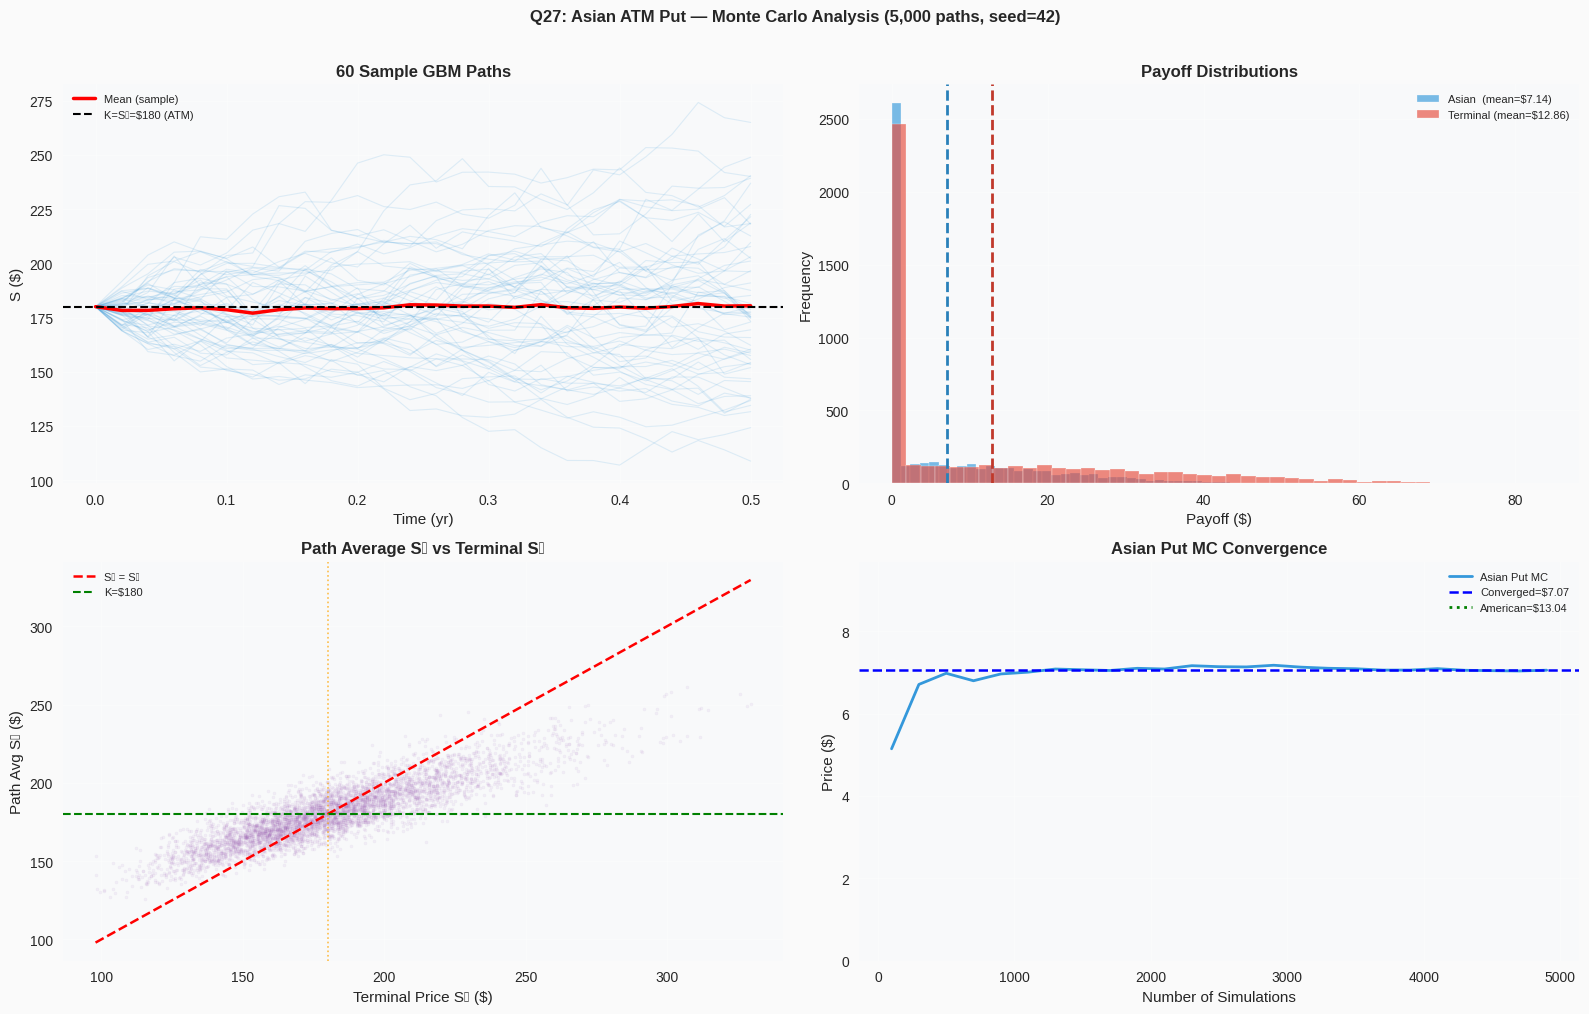

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Q27: Asian ATM Put — Monte Carlo Analysis (5,000 paths, seed=42)",
             fontsize=12, fontweight='bold', y=1.01)

# Top-left: sample GBM paths
ax = axes[0, 0]
np.random.seed(99)
sample_idx = np.random.choice(n_paths, 60, replace=False)
t_arr = np.linspace(0, T, n25+1)
for idx in sample_idx:
    ax.plot(t_arr, S_mc[idx], alpha=0.14, lw=0.8, color='#3498DB')
ax.plot(t_arr, S_mc[sample_idx].mean(axis=0), 'r-', lw=2.5, label='Mean (sample)')
ax.axhline(K_asian, color='black', ls='--', lw=1.5, label=f'K=S₀=${K_asian} (ATM)')
ax.set_title('60 Sample GBM Paths', fontweight='bold')
ax.set_xlabel('Time (yr)'); ax.set_ylabel('S ($)')
ax.legend(fontsize=8)

# Top-right: payoff distributions
ax = axes[0, 1]
ax.hist(asian_payoffs, bins=45, alpha=0.65, color='#3498DB', edgecolor='white',
        label=f'Asian  (mean=${np.mean(asian_payoffs):.2f})')
ax.hist(am_payoffs_mc, bins=45, alpha=0.65, color='#E74C3C', edgecolor='white',
        label=f'Terminal (mean=${np.mean(am_payoffs_mc):.2f})')
ax.axvline(np.mean(asian_payoffs), color='#2980B9', ls='--', lw=2)
ax.axvline(np.mean(am_payoffs_mc), color='#C0392B', ls='--', lw=2)
ax.set_title('Payoff Distributions', fontweight='bold')
ax.set_xlabel('Payoff ($)'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# Bottom-left: average vs terminal
ax = axes[1, 0]
ax.scatter(S_mc[:,-1], S_avg, alpha=0.07, s=5, color='#9B59B6')
mn = min(S_mc[:,-1].min(), S_avg.min()); mx = max(S_mc[:,-1].max(), S_avg.max())
ax.plot([mn,mx],[mn,mx], 'r--', lw=1.8, label='S̄ = Sₙ')
ax.axhline(K_asian, color='green', lw=1.5, ls='--', label=f'K=${K_asian}')
ax.axvline(K_asian, color='orange', lw=1.2, ls=':', alpha=0.7)
ax.set_title('Path Average S̄ vs Terminal Sₙ', fontweight='bold')
ax.set_xlabel('Terminal Price Sₙ ($)'); ax.set_ylabel('Path Avg S̄ ($)')
ax.legend(fontsize=8)

# Bottom-right: MC convergence
ax = axes[1, 1]
n_range   = np.arange(100, 5001, 200)
prices_cv = []
for n_s in n_range:
    np.random.seed(42)
    Z_cv = np.random.normal(size=(n_s, n25))
    S_cv = np.zeros((n_s, n25+1)); S_cv[:,0] = S0
    for t in range(n25):
        S_cv[:,t+1] = S_cv[:,t]*np.exp((r-0.5*sigma**2)*dt25+sigma*np.sqrt(dt25)*Z_cv[:,t])
    avg_cv = S_cv[:,1:].mean(axis=1)
    prices_cv.append(np.exp(-r*T)*np.mean(np.maximum(K_asian-avg_cv, 0)))

ax.plot(n_range, prices_cv, color='#3498DB', lw=2, label='Asian Put MC')
ax.axhline(asian_price,  color='blue',  ls='--', lw=1.8, label=f'Converged=${asian_price:.2f}')
ax.axhline(P_am[0,0],   color='green', ls=':',  lw=2.0, label=f'American=${P_am[0,0]:.2f}')
ax.set_title('Asian Put MC Convergence', fontweight='bold')
ax.set_xlabel('Number of Simulations'); ax.set_ylabel('Price ($)')
ax.legend(fontsize=8); ax.set_ylim(0, max(prices_cv)*1.35)

plt.tight_layout()
plt.show()

---
## Summary Comparison <a id='summary'></a>

In [30]:
print("╔" + "═"*80 + "╗")
print(f"║ {'FINAL RESULTS SUMMARY':^80} ║")
print("╠" + "═"*80 + "╣")
print(f"║ {'Feature':<30} {'European (Q25)':<18} {'American (Q26)':<18} {'Asian ATM (Q27)':<13} ║")
print("╠" + "═"*80 + "╣")
rows = [
    ("Price",               f"${P3[0,0]:.2f} (3-step)",  f"${P_am[0,0]:.2f} (25-step)", f"${asian_price:.2f} (5k MC)"),
    ("Initial Delta Δ₀",    f"{D3[0,0]:.2f}",            f"{Delta_am[0,0]:.2f}",         f"{delta_asian_0:.2f}"),
    ("Payoff basis",         "Terminal Sₙ",               "Terminal Sₙ",                  "Path avg S̄"),
    ("Early exercise",       "No",                        "Yes (25 nodes)",                "No"),
    ("Hedge type",           "Standard Δ",                "Δ + early exercise",            "Path-dep Δ (MC)"),
    ("Rebalancing events",   "3",                         "Up to 25",                      "25 (shrinking Δ)"),
]
for row in rows:
    print(f"║ {row[0]:<30} {row[1]:<18} {row[2]:<18} {row[3]:<13} ║")
print("╚" + "═"*80 + "╝")

╔════════════════════════════════════════════════════════════════════════════════╗
║                              FINAL RESULTS SUMMARY                               ║
╠════════════════════════════════════════════════════════════════════════════════╣
║ Feature                        European (Q25)     American (Q26)     Asian ATM (Q27) ║
╠════════════════════════════════════════════════════════════════════════════════╣
║ Price                          $13.82 (3-step)    $13.04 (25-step)   $7.07 (5k MC) ║
║ Initial Delta Δ₀               -0.47              -0.48              -0.46         ║
║ Payoff basis                   Terminal Sₙ        Terminal Sₙ        Path avg S̄   ║
║ Early exercise                 No                 Yes (25 nodes)     No            ║
║ Hedge type                     Standard Δ         Δ + early exercise Path-dep Δ (MC) ║
║ Rebalancing events             3                  Up to 25           25 (shrinking Δ) ║
╚═════════════════════════════════════════════════

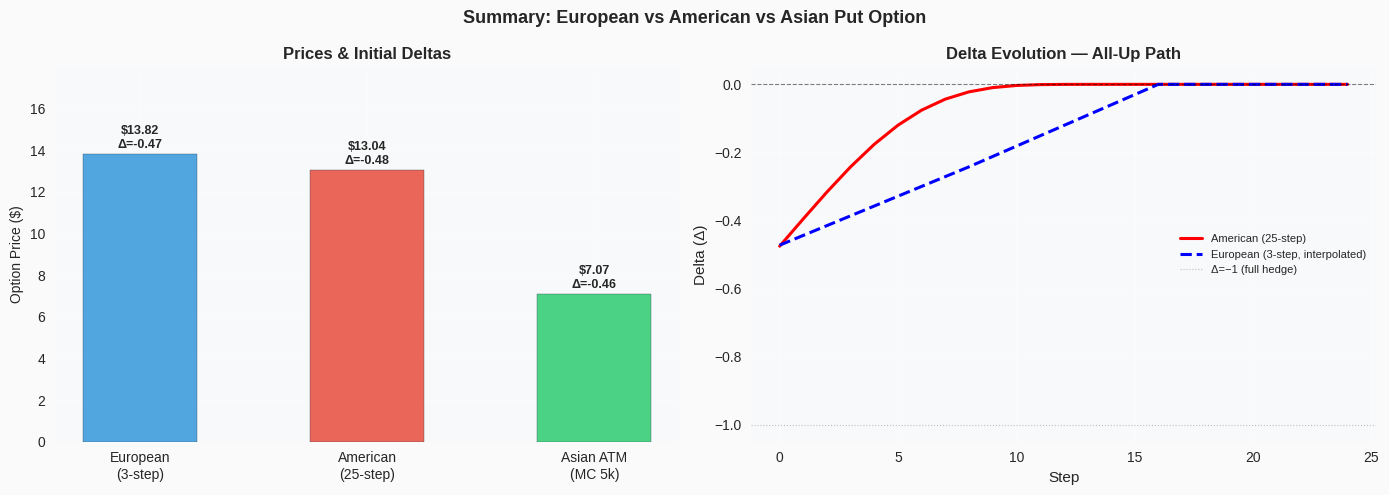


✓ All questions complete.
  European Put:  $13.82
  American Put:  $13.04
  Asian ATM Put: $7.07


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Summary: European vs American vs Asian Put Option",
             fontsize=13, fontweight='bold')

# Price comparison
ax = axes[0]
labels_s = ['European\n(3-step)', 'American\n(25-step)', 'Asian ATM\n(MC 5k)']
prices_s = [P3[0,0], P_am[0,0], asian_price]
deltas_s = [D3[0,0], Delta_am[0,0], delta_asian_0]
colors_s = ['#3498DB', '#E74C3C', '#2ECC71']

bars = ax.bar(labels_s, prices_s, color=colors_s, edgecolor='#2E4057', width=0.5, alpha=0.85)
for bar, price, delta in zip(bars, prices_s, deltas_s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
            f'${price:.2f}\nΔ={delta:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Option Price ($)', fontsize=10)
ax.set_title('Prices & Initial Deltas', fontweight='bold')
ax.set_ylim(0, max(prices_s)*1.30)

# Delta evolution comparison
ax = axes[1]
eu_interp = np.interp(np.linspace(0,1,n25), [0,1/3,2/3], [D3[0,0],D3[1,0],D3[2,0]])
ax.plot(range(n25), path_delta25, 'r-',  lw=2.2, label='American (25-step)')
ax.plot(range(n25), eu_interp,    'b--', lw=2.2, label='European (3-step, interpolated)')
ax.axhline( 0, color='k',    lw=0.8, ls='--', alpha=0.5)
ax.axhline(-1, color='gray', lw=0.8, ls=':',  alpha=0.5, label='Δ=−1 (full hedge)')
ax.set_xlabel('Step'); ax.set_ylabel('Delta (Δ)')
ax.set_title('Delta Evolution — All-Up Path', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ All questions complete.")
print(f"  European Put:  ${P3[0,0]:.2f}")
print(f"  American Put:  ${P_am[0,0]:.2f}")
print(f"  Asian ATM Put: ${asian_price:.2f}")